# Test — LeakyBucketLocal (Australia / camelsaus_102101A)

Quick end-to-end test of `LeakyBucketLocal` using the ERA5 forcing for the
Australian catchment **camelsaus_102101A**.  
Observed discharge from the Caravan dataset is loaded for visual comparison.

Steps:
1. Load settings & forcing
2. Run the model for a range of `leakiness` values
3. Plot modelled vs observed discharge

In [1]:
import sys
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from rich import print

# Make sure the scripts folder is importable both on HPC and locally
try:
    from scripts.leakybucket_model import LeakyBucketLocal
except ImportError:
    project_root = Path().resolve().parent
    sys.path.insert(0, str(project_root))
    from scripts.leakybucket_model import LeakyBucketLocal

import ewatercycle
import ewatercycle.forcing

## 1. Settings & forcing

In [2]:
settings_file = Path('settings.json')
with open(settings_file) as f:
    settings = json.load(f)

print(f"Catchment : [cyan]{settings['caravan_id']}[/cyan]")
print(f"Calibration: {settings['calibration_start_date']} → {settings['calibration_end_date']}")
print(f"Validation : {settings['validation_start_date']} → {settings['validation_end_date']}")

Catchment : camelsaus_102101A

Calibration: 1994-08-01T00:00:00Z → 2004-07-31T00:00:00Z

Validation : 2004-08-01T00:00:00Z → 2014-07-31T00:00:00Z

In [3]:
# ERA5 forcing — stored one level deeper than path_ERA5
era5_dir = Path(settings['path_ERA5']) / 'work' / 'diagnostic' / 'script'
era5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].load(directory=era5_dir)
display(era5_forcing)

LumpedMakkinkForcing(start_time='1994-08-01T00:00:00Z', end_time='2014-07-31T00:00:00Z', directory=PosixPath('/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/ERA5/work/diagnostic/script'), shape=PosixPath('/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/ERA5/work/diagnostic/script/camelsaus_102101A.shp'), filenames={'pr': 'OBS6_ERA5_reanaly_1_day_pr_1994-2014.nc', 'tas': 'OBS6_ERA5_reanaly_1_day_tas_1994-2014.nc', 'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_1994-2014.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'})

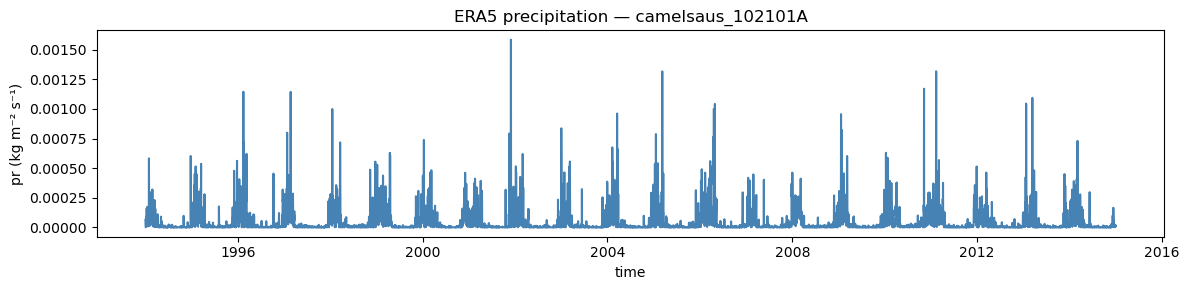

In [4]:
# Quick look at the precipitation input
pr = xr.open_dataset(era5_forcing.directory / era5_forcing['pr'])['pr']
pr.plot(figsize=(12, 3), color='steelblue')
plt.title('ERA5 precipitation — camelsaus_102101A')
plt.ylabel('pr (kg m⁻² s⁻¹)')
plt.tight_layout()
plt.show()

In [5]:
# Observed discharge from Caravan (for comparison)
caravan_forcing = ewatercycle.forcing.sources['CaravanForcing'].load(
    directory=settings['path_caravan']
)
obs_q = xr.open_dataset(
    caravan_forcing.directory / caravan_forcing['Q']
)['Q'].to_series()
obs_q.name = 'Observed (Caravan)'
print(f"Observed discharge: {len(obs_q)} days, "
      f"{obs_q.index[0].date()} → {obs_q.index[-1].date()}")

print(obs_q)

Observed discharge: 7305 days, 1994-08-01 → 2014-07-31

date
1994-08-01    0.17
1994-08-02    0.17
1994-08-03    0.17
1994-08-04    0.18
1994-08-05    0.18
              ... 
2014-07-27    0.26
2014-07-28    0.25
2014-07-29    0.25
2014-07-30    0.24
2014-07-31    0.23
Name: Observed (Caravan), Length: 7305, dtype: float32

## 2. Run LeakyBucketLocal

Run for several `leakiness` values to explore the model's sensitivity.
The bucket equation is `Q = leakiness × S`, so a higher value drains faster.

In [6]:
LEAKINESS_VALUES = np.linspace(0.01, 2, 20)  # d⁻¹
INITIAL_STORAGE  = 0.0                    # m

model_output = {}

for leakiness in LEAKINESS_VALUES:
    label = f'leakiness={leakiness}'
    # print(f'Running [cyan]{label}[/cyan] ...')

    model = LeakyBucketLocal(forcing=era5_forcing)
    config_file, _ = model.setup(leakiness=leakiness, initial_storage=INITIAL_STORAGE)
    model.initialize(config_file)

    q_vals, timestamps = [], []
    while model.time < model.end_time:
        model.update()
        q_vals.append(model.get_value('discharge')[0])
        timestamps.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    model_output[label] = pd.Series(data=q_vals, index=timestamps, name=label)
    # print(f'  → {len(q_vals)} timesteps, '
    #       f'mean Q = {np.mean(q_vals):.4f} m/d')

print('[bold green]All runs complete.[/bold green]')

All runs complete.

## 3. Plot — modelled discharge vs observed

In [7]:
# print(model_output)

# plt.plot(model_output['leakiness=0.1'])

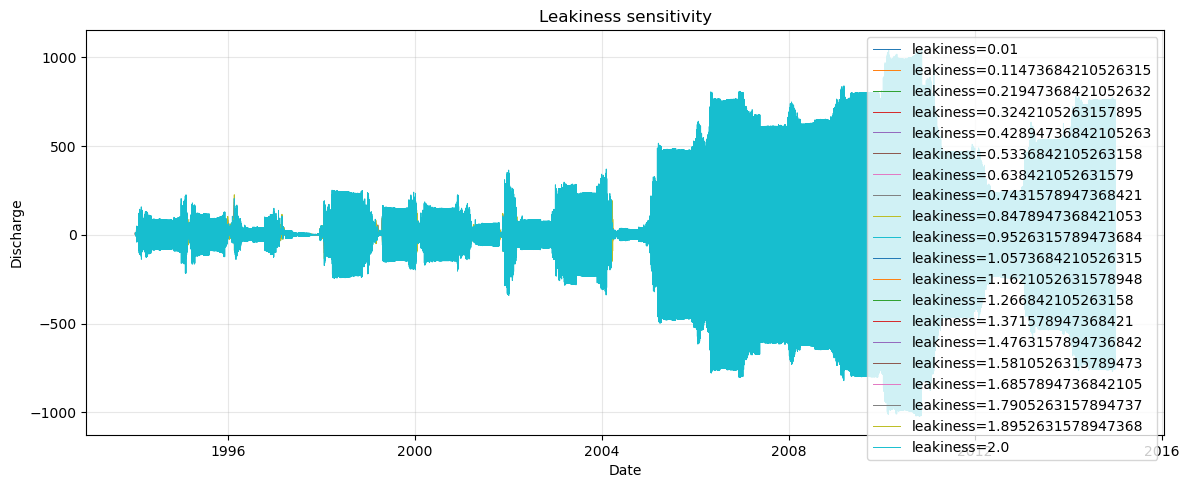

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, series in model_output.items():
    ax.plot(series.index, series.values, label=label, linewidth=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('Discharge')
ax.set_title('Leakiness sensitivity')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Performance metrics (KGE / NSE)

Quick check against the calibration period used in `settings.json`.

In [9]:
def kge(sim, obs):
    """Kling-Gupta Efficiency."""
    mask = ~(np.isnan(sim) | np.isnan(obs))
    s, o = sim[mask], obs[mask]
    r = np.corrcoef(s, o)[0, 1]
    alpha = s.std() / o.std()
    beta  = s.mean() / o.mean()
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def nse(sim, obs):
    """Nash-Sutcliffe Efficiency."""
    mask = ~(np.isnan(sim) | np.isnan(obs))
    s, o = sim[mask], obs[mask]
    return 1 - np.sum((s - o)**2) / np.sum((o - o.mean())**2)


cal_start = settings['calibration_start_date'][:10]
cal_end   = settings['calibration_end_date'][:10]

obs_daily = obs_q.copy()
obs_daily.index = obs_daily.index.normalize()

rows = []
for label, series in model_output.items():
    sim = series[cal_start:cal_end].copy()
    sim.index = sim.index.normalize()
    obs = obs_daily.reindex(sim.index)
    rows.append({
        'run':   label,
        'KGE':   kge(sim.values, obs.values),
        'NSE':   nse(sim.values, obs.values),
        'mean_sim (m/d)': sim.mean(),
        'mean_obs (m/d)': obs.mean(),
    })

metrics = pd.DataFrame(rows).set_index('run')
display(metrics.style.format('{:.4f}').highlight_max(
    subset=['KGE', 'NSE'], color='#c8f7c5'
).set_caption(f'Calibration period: {cal_start} → {cal_end}'))

,KGE,NSE,mean_sim (m/d),mean_obs (m/d)
run,,,,
leakiness=0.01,-0.0761,0.1059,3.8916,2.7557
leakiness=0.11473684210526315,0.1922,0.2241,3.9263,2.7557
leakiness=0.21947368421052632,0.2439,0.2454,3.9262,2.7557
leakiness=0.3242105263157895,0.2727,0.2401,3.9262,2.7557
leakiness=0.42894736842105263,0.2873,0.2141,3.9262,2.7557
leakiness=0.5336842105263158,0.2926,0.1734,3.9261,2.7557
leakiness=0.638421052631579,0.2915,0.1217,3.9261,2.7557
leakiness=0.7431578947368421,0.2857,0.0604,3.9261,2.7557
leakiness=0.8478947368421053,0.2761,-0.0103,3.9260,2.7557


In [10]:
!rm -rf leakybucketlocal_202*